In [1]:
import pandas as pd

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "winterForestStump/10-K_sec_filings",
    streaming=True
)

# we take only the first 2000 rows to avoid computer crash
df = pd.DataFrame(list(dataset["001"].take(2000)))
print(df.shape)
print(df.columns.tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

(2000, 23)
['cik', 'company_name', 'filing_date', 'Business', 'Risk Factors', 'Unresolved Staff Comments', 'Properties', 'Legal Proceedings', 'Mine Safety Disclosures', 'Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities', 'Selected Financial Data', 'Management’s Discussion and Analysis of Financial Condition and Results of Operations', 'Quantitative and Qualitative Disclosures about Market Risk', 'Financial Statements and Supplementary Data', 'Changes in and Disagreements with Accountants on Accounting and Financial Disclosure', 'Controls and Procedures', 'Other Information', 'Directors, Executive Officers and Corporate Governance', 'Executive Compensation', 'Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters', 'Certain Relationships and Related Transactions, and Director Independence', 'Principal Accountant Fees and Services', 'Exhibits, Financial Statement Schedules']


In [3]:
df.head()

,cik,company_name,filing_date,Business,Risk Factors,Unresolved Staff Comments,Properties,Legal Proceedings,Mine Safety Disclosures,"Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities",...,Financial Statements and Supplementary Data,Changes in and Disagreements with Accountants on Accounting and Financial Disclosure,Controls and Procedures,Other Information,"Directors, Executive Officers and Corporate Governance",Executive Compensation,Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters,"Certain Relationships and Related Transactions, and Director Independence",Principal Accountant Fees and Services,"Exhibits, Financial Statement Schedules"
0,1044324,TROPICAL SPORTSWEAR INTERNATIONAL CORP,1999-01-04,General The Company produces high ...,,,The Company's corporate headquarters are loca...,"On March 21, 1997, Levi Straus & Co. brought...",Not applicable. ...,The Company's Common Stock has been traded...,...,The information called for by this Item is...,None. PART III,,,"The information under the captions ""Electio...","The information under the captions ""E...","The information under the caption ""Electio...","The information under the caption ""Election...",(a) 1. Index to Financial Statements ...,
1,320303,METAL ARTS CO INC,1999-01-04,,,,,,,,...,,,,,,,,,,
2,792130,DATAWATCH CORP,1998-12-29,,,,The Company is currently headquartered in ...,"On November 12, 1998, the Company brought a ...",No matters were submitted to a vote of the Re...,The Registrant's common stock is listed an...,...,The information required by this item is set f...,,,,,The information set forth under the capti...,"The information set forth under the caption ""...",The information set forth under the capt...,The following documents are filed as part of t...,
3,851478,BEI MEDICAL SYSTEMS CO INC /DE/,1999-01-04,"BEI Medical Systems Company, Inc. (""BEI ...",,,The Company's principal executive offices ...,"In July 1998, the Company settled a law...",None. ...,The Company's common stock was initially offer...,...,CONSOLIDATED BALANCE SHEETS BEI Medical System...,None ...,,,Certain information with respect to directors ...,The information required by this Item is inco...,The information required by this Item is inco...,The information required by this Item is inco...,The following documents are filed as part of t...,
4,884124,GALEY & LORD INC,1999-01-04,This 1998 Annual Report on Form 10-K contains ...,,,The following table sets forth the general loc...,"During fiscal 1998, South Carolina environment...",None. ...,"The Company's common stock, $.01 par value, (t...",...,REPORT OF INDEPENDENT AUDITORS Board of Di...,None. ...,,,The information required by this item is incor...,The information required by this item is incor...,The information required by this item is incor...,The information required by this item is incor...,(a) 1. Financial Statements The ...,


In [4]:
# checking if any cell has null value
df.isnull().sum()

,0
cik,0
company_name,0
filing_date,0
Business,0
Risk Factors,0
Unresolved Staff Comments,0
Properties,0
Legal Proceedings,0
Mine Safety Disclosures,0
"Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities",0


In [5]:
# we can clearly see that risk factor cell is empty but is not 'null' which means it has spaces in it
i = 1
for column in df.columns:
    non_empty = df[column].astype(str).str.strip().ne("").sum()
    print(f"{i}. {column} : {non_empty}")
    i += 1

1. cik : 2000
2. company_name : 2000
3. filing_date : 2000
4. Business : 1319
5. Risk Factors : 8
6. Unresolved Staff Comments : 0
7. Properties : 1457
8. Legal Proceedings : 1452
9. Mine Safety Disclosures : 1461
10. Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities : 1472
11. Selected Financial Data : 1400
12. Management’s Discussion and Analysis of Financial Condition and Results of Operations : 1378
13. Quantitative and Qualitative Disclosures about Market Risk : 869
14. Financial Statements and Supplementary Data : 1426
15. Changes in and Disagreements with Accountants on Accounting and Financial Disclosure : 1350
16. Controls and Procedures : 0
17. Other Information : 0
18. Directors, Executive Officers and Corporate Governance : 1354
19. Executive Compensation : 1314
20. Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters : 1333
21. Certain Relationships and Related Transactions

In [6]:
# first 4 columns give info about company so they are useless for our model. Columns like 5, 6 are mostly empty and and of no use to our model
# the most data rich columns are columns like 7,8,9,10,11...

In [7]:
# Pick the most useful text columns
text_columns = [
    'Business',
    'Management’s Discussion and Analysis of Financial Condition and Results of Operations',
    'Legal Proceedings'
]

# Combine them into one text per row
df['raw_text'] = df[text_columns].fillna('').agg(' '.join, axis=1)

print(df['raw_text'].iloc[0])

General           The Company  produces  high quality  casual and dress men's and women's apparel and provides major apparel retailers with comprehensive brand management programs. The Company's programs currently feature pants, shorts, shirts, coats, and denim  jeans for men and on a limited  basis,  pants and  skirts  for women. These  products are marketed under Company  brands,  private brands and licensed brand names. The Company  distinguishes  itself by providing  apparel  retailers with  customer,   product  and  market  analysis,  apparel  design,  production, merchandising,  and  inventory  forecasting.  The  Company  markets  its apparel through  all  major  retail  distribution  channels,  including  department  and specialty  stores,  national  chains,  catalog  retailers,   discount  and  mass merchants  and  wholesale  clubs.  The  Company's  mission is to  provide  total customer  satisfaction  through a combination of quality,  value and technology. Management  believe

In [8]:
import re

def clean_text(text):
    # Remove newlines and tabs
    text = re.sub(r'\s+', ' ', text)

    # Remove non-alphabet characters like punctuation and symbols
    text = re.sub(r'[^a-z A-Z ]', '', text)

    # Convert to lowercase
    text = text.lower()

    return text

df['clean_text'] = df['raw_text'].apply(clean_text)

print(df['clean_text'].iloc[0])

general the company produces high quality casual and dress mens and womens apparel and provides major apparel retailers with comprehensive brand management programs the companys programs currently feature pants shorts shirts coats and denim jeans for men and on a limited basis pants and skirts for women these products are marketed under company brands private brands and licensed brand names the company distinguishes itself by providing apparel retailers with customer product and market analysis apparel design production merchandising and inventory forecasting the company markets its apparel through all major retail distribution channels including department and specialty stores national chains catalog retailers discount and mass merchants and wholesale clubs the companys mission is to provide total customer satisfaction through a combination of quality value and technology management believes that the company provides its customers with high quality apparel and services supported by a 

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = vectorizer.fit_transform(df['clean_text'])

print(X.shape)


(2000, 5000)


In [10]:
# Define risk keywords
high_risk_words = ['risk', 'loss', 'lawsuit', 'litigation', 'debt', 'default',
                   'bankruptcy', 'decline', 'adverse', 'uncertainty', 'volatile',
                   'penalty', 'fraud', 'investigation', 'deficit', 'impairment']

low_risk_words = ['growth', 'profit', 'revenue', 'increase', 'success', 'strong',
                  'positive', 'opportunity', 'expansion', 'improvement', 'gain',
                  'efficient', 'innovative', 'leading', 'competitive']

def assign_label(text):
    text = text.lower()

    high_score = sum(text.count(word) for word in high_risk_words)
    low_score = sum(text.count(word) for word in low_risk_words)

    if high_score > low_score * 1.1:
        return 'high'
    elif low_score > high_score * 1.1:
        return 'low'
    else:
        return 'medium'

df['label'] = df['clean_text'].apply(assign_label)

# Check label distribution
print(df['label'].value_counts())

label
low       924
medium    646
high      430
Name: count, dtype: int64


In [11]:
import numpy as np
from scipy.sparse import hstack, csr_matrix

# Custom features
df['doc_length'] = df['clean_text'].apply(lambda x: len(x.split()))
df['high_risk_count'] = df['clean_text'].apply(lambda x: sum(x.count(w) for w in high_risk_words))
df['low_risk_count'] = df['clean_text'].apply(lambda x: sum(x.count(w) for w in low_risk_words))
df['risk_ratio'] = df['high_risk_count'] / (df['low_risk_count'] + 1)

# Combine TF-IDF with custom features
custom_features = csr_matrix(df[['doc_length', 'high_risk_count', 'low_risk_count', 'risk_ratio']].values)

X_combined = hstack([X, custom_features])
print("Combined feature shape:", X_combined.shape)

Combined feature shape: (2000, 5004)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['label'])

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1600, 5004)
Test size: (400, 5004)


In [19]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)


AdaBoostClassifier(n_estimators=100, random_state=42)

In [16]:
!pip install catboost

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
cat_model.fit(X_train, y_train)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
CatBoost trained


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    'XGBoost': xgb_model,
    'AdaBoost': ada_model,
    'CatBoost': cat_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")


Model: XGBoost
Accuracy:  0.9875
Precision: 0.9876
Recall:    0.9875
F1 Score:  0.9875
Confusion Matrix:
[[ 86   0   0]
 [  0 184   1]
 [  2   2 125]]

Model: AdaBoost
Accuracy:  0.9600
Precision: 0.9610
Recall:    0.9600
F1 Score:  0.9595
Confusion Matrix:
[[ 86   0   0]
 [  0 183   2]
 [  3  11 115]]

Model: CatBoost
Accuracy:  0.9750
Precision: 0.9752
Recall:    0.9750
F1 Score:  0.9749
Confusion Matrix:
[[ 86   0   0]
 [  0 183   2]
 [  1   7 121]]


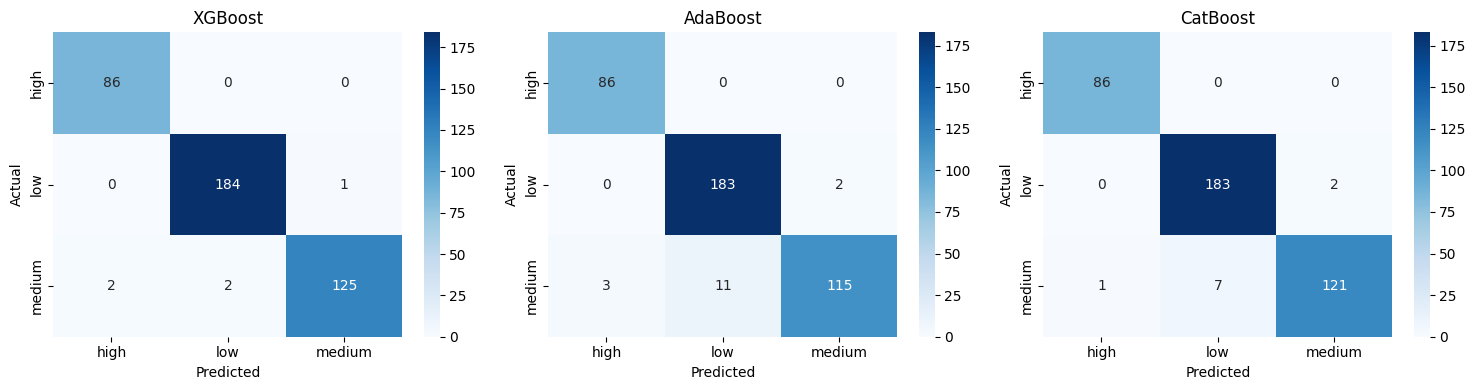

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = le.classes_

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=labels, yticklabels=labels, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

FileNotFoundError: Cannot find file: xgb_model.joblib